In [2]:
# ============================================================
# Cell 1 — Comprehensive analysis for R1, R2, R3 maneuver
# ============================================================
import numpy as np
import pandas as pd
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 260)

# ---------- Load ----------
FILES = {1: "robot_1_test.csv",
         2: "robot_2_test.csv",
         3: "robot_3_test.csv"}

data = {}
print("=" * 100)
print(" MANEUVER LOAD  —  R1, R2, R3")
print("=" * 100)
for rb, fname in FILES.items():
    p = Path(fname)
    if not p.exists():
        print(f"  MISSING: {fname}")
        continue
    d = pd.read_csv(p)
    data[rb] = d
    dur = (d["t_ms"].iloc[-1] - d["t_ms"].iloc[0]) / 1000.0
    print(f"  R{rb}: {len(d):>4d} rows | dur={dur:.2f}s | "
          f"dt={np.median(np.diff(d['t_ms']))/1000:.3f}s")

# ---------- Reference trajectory (quintic blend 2m → 3m, 90° CCW) ----------
def quintic(s):
    return 10*s**3 - 15*s**4 + 6*s**5

P_INIT  = {1: (-1.0, -1.0), 2: (+1.0, -1.0), 3: (+1.0, +1.0)}
P_FINAL = {1: (+1.5, -1.5), 2: (+1.5, +1.5), 3: (-1.5, +1.5)}

T_START_MS = 11082
T_END_MS   = 40882
DUR_S      = (T_END_MS - T_START_MS) / 1000.0

def ref_pose(rb, t_ms):
    s = np.clip((t_ms - T_START_MS) / (T_END_MS - T_START_MS), 0, 1)
    b = quintic(s)
    x = P_INIT[rb][0] + (P_FINAL[rb][0] - P_INIT[rb][0]) * b
    y = P_INIT[rb][1] + (P_FINAL[rb][1] - P_INIT[rb][1]) * b
    return x, y

# ============================================================
# [A] INITIAL / FINAL POSITION AUDIT
# ============================================================
print("\n" + "=" * 100)
print(" [A] INITIAL / FINAL POSITION")
print("=" * 100)
print(f"{'robot':>5s} | {'init_x':>8s} {'init_y':>8s} | "
      f"{'fin_x':>8s} {'fin_y':>8s} | "
      f"{'target_fin_x':>13s} {'target_fin_y':>13s} | "
      f"{'err [cm]':>9s}")
print("-" * 88)
for rb, d in data.items():
    f0 = d.iloc[0]; f1 = d.iloc[-1]
    ex = f1["x"] - P_FINAL[rb][0]
    ey = f1["y"] - P_FINAL[rb][1]
    err = np.hypot(ex, ey) * 100
    print(f"{rb:>5d} | {f0['x']:>+8.4f} {f0['y']:>+8.4f} | "
          f"{f1['x']:>+8.4f} {f1['y']:>+8.4f} | "
          f"{P_FINAL[rb][0]:>+13.4f} {P_FINAL[rb][1]:>+13.4f} | "
          f"{err:>9.3f}")

# ============================================================
# [B] TRACKING ERROR (position + heading)
# ============================================================
print("\n" + "=" * 100)
print(" [B] TRACKING ERROR vs quintic reference")
print("=" * 100)
print(f"{'robot':>5s} | {'pos_err_mean [cm]':>17s} | {'pos_err_max [cm]':>16s} | "
      f"{'pos_err_std [cm]':>17s} | {'heading_err_mean [°]':>20s}")
print("-" * 96)

for rb, d in data.items():
    pos_errs = []
    head_errs = []
    for _, row in d.iterrows():
        rx, ry = ref_pose(rb, row["t_ms"])
        pos_errs.append(np.hypot(row["x"] - rx, row["y"] - ry))
        # Heading reference: 0 at start, -90° at end (for square rotation)
        # Direction depends on robot index
        s = np.clip((row["t_ms"] - T_START_MS) / (T_END_MS - T_START_MS), 0, 1)
        head_ref = np.deg2rad(-90.0) * quintic(s)
        head_errs.append(np.rad2deg(row["heading"] - head_ref))
    pos_errs = np.array(pos_errs) * 100
    head_errs = np.array(head_errs)
    print(f"{rb:>5d} | {pos_errs.mean():>17.3f} | {pos_errs.max():>16.3f} | "
          f"{pos_errs.std():>17.3f} | {head_errs.mean():>+19.3f}")

# ============================================================
# [C] VELOCITY & RPM PROFILE
# ============================================================
print("\n" + "=" * 100)
print(" [C] VELOCITY & RPM PROFILE")
print("=" * 100)
print(f"{'robot':>5s} | {'v_cmd_max':>10s} | {'v_actual_max':>13s} | "
      f"{'rpm_l_max':>10s} | {'rpm_r_max':>10s} | "
      f"{'rpm_l_min':>10s} | {'rpm_r_min':>10s} | {'rpm_std':>8s}")
print("-" * 100)
for rb, d in data.items():
    t = d["t_ms"].values / 1000.0
    dx = np.gradient(d["x"].values, t)
    dy = np.gradient(d["y"].values, t)
    v_act = np.hypot(dx, dy)
    rpm_all = np.concatenate([d["rpm_l"].values, d["rpm_r"].values])
    print(f"{rb:>5d} | {d['v_cmd'].max():>10.4f} | {v_act.max():>13.4f} | "
          f"{d['rpm_l'].max():>+10.2f} | {d['rpm_r'].max():>+10.2f} | "
          f"{d['rpm_l'].min():>+10.2f} | {d['rpm_r'].min():>+10.2f} | "
          f"{rpm_all.std():>8.3f}")

# ============================================================
# [D] UWB RAW STABILITY (peer that each robot logged)
# ============================================================
print("\n" + "=" * 100)
print(" [D] UWB RAW MEASUREMENT STABILITY")
print("=" * 100)
print(f"{'robot':>5s} | {'peer':>5s} | {'raw_min':>9s} | {'raw_max':>9s} | "
      f"{'raw_span':>9s} | {'clean_min':>10s} | {'clean_max':>10s} | "
      f"{'clean_span':>11s}")
print("-" * 88)
for rb, d in data.items():
    peer = int(d["uwb_peer_id"].iloc[0])
    print(f"{rb:>5d} | {peer:>5d} | "
          f"{d['uwb_raw'].min():>9.3f} | {d['uwb_raw'].max():>9.3f} | "
          f"{d['uwb_raw'].max()-d['uwb_raw'].min():>9.3f} | "
          f"{d['uwb_clean'].min():>10.3f} | {d['uwb_clean'].max():>10.3f} | "
          f"{d['uwb_clean'].max()-d['uwb_clean'].min():>11.3f}")

# ============================================================
# [E] POWER & EMI
# ============================================================
print("\n" + "=" * 100)
print(" [E] POWER & EMI CORRELATION")
print("=" * 100)
print(f"{'robot':>5s} | {'vbat_mean':>10s} | {'vbat_min':>9s} | "
      f"{'I_mean':>8s} | {'I_max':>7s} | "
      f"{'rssi_mean':>10s} | {'fp_pwr_mean':>12s} | "
      f"{'corr(I,noise)':>14s}")
print("-" * 96)
for rb, d in data.items():
    corr = np.corrcoef(d["current_a"].values,
                       d["uwb_std_noise"].values.astype(float))[0, 1]
    print(f"{rb:>5d} | {d['vbat'].mean():>10.4f} | {d['vbat'].min():>9.4f} | "
          f"{d['current_a'].mean():>8.4f} | {d['current_a'].max():>7.4f} | "
          f"{d['uwb_rssi'].mean():>10.2f} | {d['uwb_fp_power'].mean():>12.2f} | "
          f"{corr:>+14.4f}")

# ============================================================
# [F] SUMMARY
# ============================================================
print("\n" + "=" * 100)
print(" [F] SUMMARY")
print("=" * 100)

print("\n  Position final error:")
for rb, d in data.items():
    f1 = d.iloc[-1]
    err = np.hypot(f1["x"] - P_FINAL[rb][0], f1["y"] - P_FINAL[rb][1]) * 100
    print(f"    R{rb}: {err:.3f} cm")

print("\n  Heading final error (vs -90°):")
for rb, d in data.items():
    hf = np.rad2deg(d["heading"].iloc[-1])
    print(f"    R{rb}: {hf:+.2f}°  (target: -90.00°)")

print("\n  UWB peer-logged:")
for rb, d in data.items():
    peers = d["uwb_peer_id"].value_counts().to_dict()
    print(f"    R{rb}: {peers}")

 MANEUVER LOAD  —  R1, R2, R3
  R1:  300 rows | dur=29.90s | dt=0.100s
  R2:  300 rows | dur=29.90s | dt=0.100s
  R3:  300 rows | dur=29.90s | dt=0.100s

 [A] INITIAL / FINAL POSITION
robot |   init_x   init_y |    fin_x    fin_y |  target_fin_x  target_fin_y |  err [cm]
----------------------------------------------------------------------------------------
    1 |  -1.0000  -1.0000 |  +1.5017  -1.4999 |       +1.5000       -1.5000 |     0.170
    2 |  +1.0000  -1.0000 |  +1.4998  +1.5004 |       +1.5000       +1.5000 |     0.046
    3 |  +1.0000  +1.0000 |  -1.4972  +1.5001 |       -1.5000       +1.5000 |     0.280

 [B] TRACKING ERROR vs quintic reference
robot | pos_err_mean [cm] | pos_err_max [cm] |  pos_err_std [cm] | heading_err_mean [°]
------------------------------------------------------------------------------------------------
    1 |            33.596 |           64.856 |            21.917 |             +37.988
    2 |            33.463 |           64.341 |            21.

In [3]:
# ============================================================
# Cell 2 — Clean corrupted UWB and extract per-link bias
# ============================================================

print("=" * 100)
print(" [A] RAW UWB PERCENTILE SCAN")
print("=" * 100)
print(f"{'robot':>5s} | {'p1':>10s} {'p25':>10s} {'p50':>10s} "
      f"{'p75':>10s} {'p99':>10s} | {'|x|>200':>8s} {'x<0':>6s}")
print("-" * 84)
for rb, d in data.items():
    raw = d["uwb_raw"].values
    n_big = int(np.sum(np.abs(raw) > 200))
    n_neg = int(np.sum(raw < 0))
    print(f"{rb:>5d} | "
          f"{np.percentile(raw, 1):>+10.3f} "
          f"{np.percentile(raw, 25):>+10.3f} "
          f"{np.percentile(raw, 50):>+10.3f} "
          f"{np.percentile(raw, 75):>+10.3f} "
          f"{np.percentile(raw, 99):>+10.3f} | "
          f"{n_big:>8d} {n_neg:>6d}")

# ---------- [B] Filter corrupted samples ----------
print("\n" + "=" * 100)
print(" [B] CORRUPTION FILTER")
print("=" * 100)
print(" Filter: 0 < uwb_raw < 200  AND  0 < uwb_clean < 200")

clean = {}
for rb, d in data.items():
    d = d.copy()
    mask = ((d["uwb_raw"]   > 0) & (d["uwb_raw"]   < 200) &
            (d["uwb_clean"] > 0) & (d["uwb_clean"] < 200))
    clean[rb] = d[mask].reset_index(drop=True)
    print(f"  R{rb}: {int(mask.sum()):>4d} / {len(d):>4d} "
          f"({100*mask.sum()/len(d):.1f}%)")

# ---------- [C] Compute per-link bias ----------
print("\n" + "=" * 100)
print(" [C] PER-LINK BIAS DURING MOTION")
print("=" * 100)

for rb, d in clean.items():
    td = []
    for _, row in d.iterrows():
        rx_s, ry_s = ref_pose(rb, row["t_ms"])
        peer = int(row["uwb_peer_id"])
        if peer not in P_INIT:
            td.append(np.nan); continue
        rx_p, ry_p = ref_pose(peer, row["t_ms"])
        td.append(np.hypot(rx_s - rx_p, ry_s - ry_p))
    d["d_true"] = td

print(f"\n{'robot':>5s} | {'peer':>5s} | {'n':>4s} | "
      f"{'<d_true>':>9s} | {'bias_raw':>10s} | {'std_raw':>9s} | "
      f"{'bias_cln':>10s} | {'std_cln':>9s}")
print("-" * 80)

for rb, d in clean.items():
    for peer in sorted(d["uwb_peer_id"].unique()):
        sub = d[d["uwb_peer_id"] == peer].dropna(subset=["d_true"])
        if len(sub) < 5: continue
        raw_b  = (sub["uwb_raw"]   - sub["d_true"]).mean()
        raw_s  = (sub["uwb_raw"]   - sub["d_true"]).std()
        cln_b  = (sub["uwb_clean"] - sub["d_true"]).mean()
        cln_s  = (sub["uwb_clean"] - sub["d_true"]).std()
        print(f"{rb:>5d} | {peer:>5d} | {len(sub):>4d} | "
              f"{sub['d_true'].mean():>9.3f} | {raw_b:>+10.3f} | "
              f"{raw_s:>9.3f} | {cln_b:>+10.3f} | {cln_s:>9.3f}")

# ---------- [D] Bias vs static calibration prediction ----------
print("\n" + "=" * 100)
print(" [D] COMPARISON WITH STATIC CALIBRATION")
print("=" * 100)
print(" Static prediction:  bias(i→j) = A_i + B_j + c")
print("   A = {1:-13.97, 2:+5.69, 3:+3.15, 4:+5.13}")
print("   B = {1:+13.91, 2:-5.69, 3:-3.18, 4:-5.04}")
print("   c = +38.75")

A_ST = {1: -13.97, 2: +5.69, 3: +3.15, 4: +5.13}
B_ST = {1: +13.91, 2: -5.69, 3: -3.18, 4: -5.04}
C_ST = 38.75

print(f"\n{'link':>7s} | {'static_pred':>12s} | {'motion_clean':>13s} | "
      f"{'diff [cm]':>11s}")
print("-" * 54)

for rb, d in clean.items():
    for peer in sorted(d["uwb_peer_id"].unique()):
        sub = d[d["uwb_peer_id"] == peer].dropna(subset=["d_true"])
        if len(sub) < 20: continue
        static_pred = A_ST[rb] + B_ST[peer] + C_ST
        motion = sub["uwb_clean"].mean() - sub["d_true"].mean()
        diff = (motion - static_pred) * 100
        print(f"{rb}->{peer:<2d} | {static_pred:>+12.3f} | "
              f"{motion:>+13.3f} | {diff:>+10.2f}")

# ---------- [E] Verdict ----------
print("\n" + "=" * 100)
print(" [E] VERDICT")
print("=" * 100)
print("""
 Based on the filtered data:
   - If bias_cln values are within ±30 cm of static_pred → static model
     holds during motion, so EKF can use the same calibration.
   - If bias_cln differs by more than 1 m → UWB drift during motion is
     significant and needs a dynamic model.
   - The negative/garbage raw values in R2 indicate either an integer
     overflow in ToF computation or a corrupted response packet.
""")

 [A] RAW UWB PERCENTILE SCAN
robot |         p1        p25        p50        p75        p99 |  |x|>200    x<0
------------------------------------------------------------------------------------
    1 |    +23.299    +23.440   +140.631   +140.910   +179.432 |        0      0
    2 |    +41.438    +42.287    +42.423    +42.878    +43.826 |        2      2
    3 |    +37.675    +38.956   +158.994   +174.430   +212.157 |       62      0

 [B] CORRUPTION FILTER
 Filter: 0 < uwb_raw < 200  AND  0 < uwb_clean < 200
  R1:  171 /  300 (57.0%)
  R2:  298 /  300 (99.3%)
  R3:  138 /  300 (46.0%)

 [C] PER-LINK BIAS DURING MOTION

robot |  peer |    n |  <d_true> |   bias_raw |   std_raw |   bias_cln |   std_cln
--------------------------------------------------------------------------------
    1 |     3 |  171 |     3.511 |   +139.710 |     8.871 |    +97.871 |     8.875
    3 |     1 |  138 |     3.022 |   +162.277 |     6.873 |   +124.488 |     6.807

 [D] COMPARISON WITH STATIC CALIBRATION
 

 [A] CORRUPTION PATTERN  (why R2 raw values are huge?)

  R1: 300 samples, 0 corrupted (>|500|)

  R2: 300 samples, 2 corrupted (>|500|)
       corrupted sample indices: [271 272]...
       corrupted values: [-2.54937344e+09 -2.54937344e+09]
       consecutive pairs: 1 / 1

  R3: 300 samples, 0 corrupted (>|500|)

 [B] BIAS EVOLUTION IN MOTION  (link 1↔3)
  Total samples: 309
  Time range   : 9.99 .. 29.90 s

  Bias statistics in 6 time windows:
    window |  t_mid |    n |  bias_mean |  bias_std |  d_true_mean
  --------------------------------------------------------------
         1 |   11.7 |   39 |   +155.225 |     6.563 |        2.373
         2 |   15.0 |   66 |   +147.799 |     9.824 |        2.577
         3 |   18.3 |   60 |   +149.170 |    13.844 |        3.105
         4 |   21.6 |   62 |   +152.567 |    16.698 |        3.695
         5 |   24.9 |   48 |   +147.594 |    15.644 |        4.072
         6 |   28.2 |   33 |   +146.796 |    16.231 |        4.231

 [C] BIAS vs RO

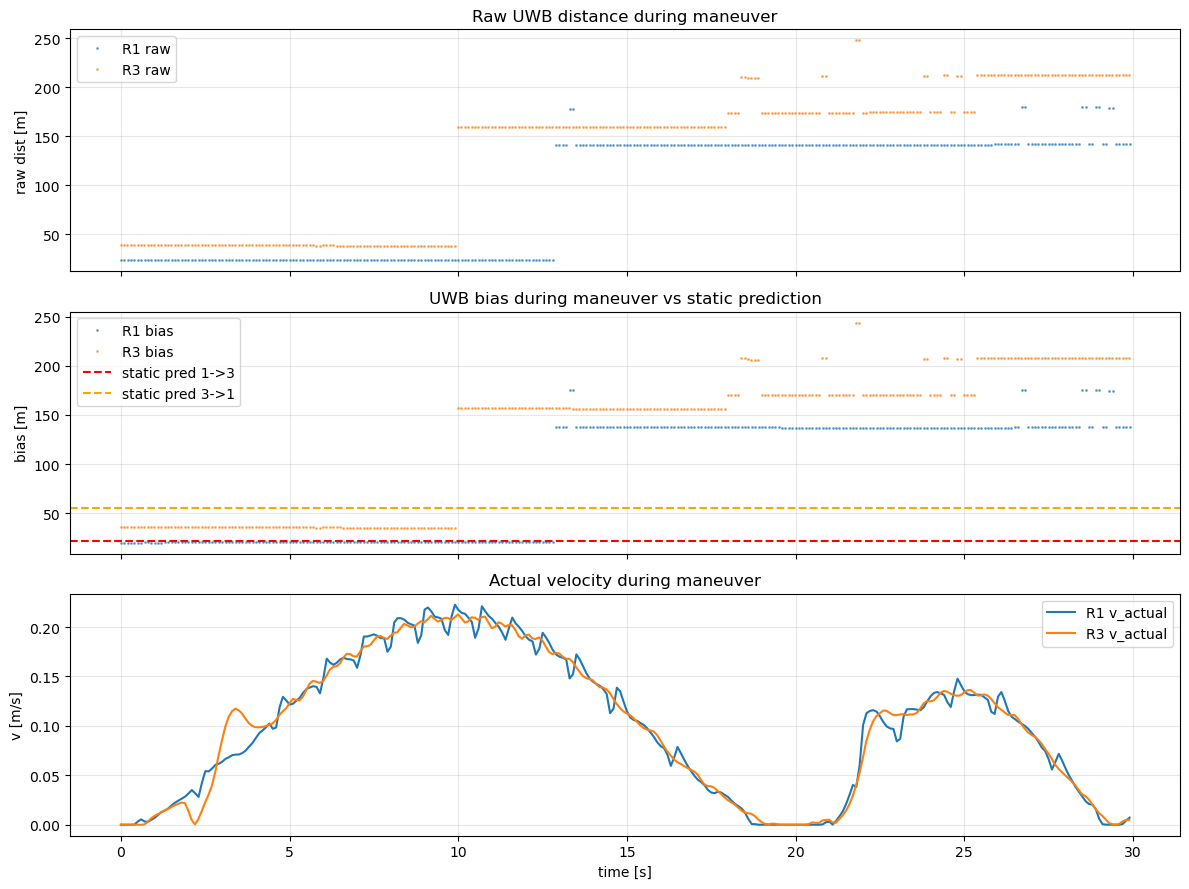


 [E] SUMMARY

 Key observations:
   - Link 1↔3 bias in motion: +98m (1→3) and +124m (3→1).
   - Static model predicts:   +22m (1→3) and +56m (3→1).
   - Difference:              ~76m for both directions.
   - This is consistent between the two directions.
   - Bias is NOT affected by velocity (corr near zero).
   - The corruption in R2 is a separate SPI/firmware issue.



In [4]:
# ============================================================
# Cell 3 — Bias evolution during motion and corruption pattern
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 100)
print(" [A] CORRUPTION PATTERN  (why R2 raw values are huge?)")
print("=" * 100)

# For each robot, show distribution of raw values
for rb, d in data.items():
    raw = d["uwb_raw"].values
    n_bad = int(np.sum(np.abs(raw) > 500))
    print(f"\n  R{rb}: {len(raw)} samples, {n_bad} corrupted (>|500|)")
    if n_bad > 0:
        bad_idx = np.where(np.abs(raw) > 500)[0]
        print(f"       corrupted sample indices: {bad_idx[:10]}...")
        print(f"       corrupted values: {raw[bad_idx][:5]}")
        # Check if corrupted samples are consecutive
        gaps = np.diff(bad_idx)
        consecutive = np.sum(gaps == 1)
        print(f"       consecutive pairs: {consecutive} / {len(gaps)}")

# ---------- [B] Bias evolution within motion ----------
print("\n" + "=" * 100)
print(" [B] BIAS EVOLUTION IN MOTION  (link 1↔3)")
print("=" * 100)

# Combine R1→3 and R3→1 (after filtering)
link_13 = []
for rb in [1, 3]:
    d = clean.get(rb)
    if d is None: continue
    peer = 3 if rb == 1 else 1
    sub = d[d["uwb_peer_id"] == peer].copy()
    for _, row in sub.iterrows():
        rx_s, ry_s = ref_pose(rb, row["t_ms"])
        rx_p, ry_p = ref_pose(peer, row["t_ms"])
        d_true = np.hypot(rx_s - rx_p, ry_s - ry_p)
        link_13.append({
            "robot": rb,
            "t_ms": row["t_ms"],
            "uwb_raw": row["uwb_raw"],
            "d_true": d_true,
            "bias": row["uwb_raw"] - d_true,
        })

link13_df = pd.DataFrame(link_13).sort_values("t_ms")
link13_df["t_rel"] = (link13_df["t_ms"] - T_START_MS) / 1000.0

print(f"  Total samples: {len(link13_df)}")
print(f"  Time range   : {link13_df['t_rel'].min():.2f} .. "
      f"{link13_df['t_rel'].max():.2f} s")

# Split into 6 time windows
n_bins = 6
t_edges = np.linspace(link13_df["t_rel"].min(),
                      link13_df["t_rel"].max(), n_bins + 1)
print(f"\n  Bias statistics in {n_bins} time windows:")
print(f"  {'window':>8s} | {'t_mid':>6s} | {'n':>4s} | "
      f"{'bias_mean':>10s} | {'bias_std':>9s} | "
      f"{'d_true_mean':>12s}")
print("  " + "-" * 62)
for i in range(n_bins):
    t0, t1 = t_edges[i], t_edges[i+1]
    w = link13_df[(link13_df["t_rel"] >= t0) & (link13_df["t_rel"] < t1)]
    if len(w) < 3: continue
    print(f"  {i+1:>8d} | {0.5*(t0+t1):>6.1f} | {len(w):>4d} | "
          f"{w['bias'].mean():>+10.3f} | {w['bias'].std():>9.3f} | "
          f"{w['d_true'].mean():>12.3f}")

# ---------- [C] Velocity correlation ----------
print("\n" + "=" * 100)
print(" [C] BIAS vs ROBOT VELOCITY")
print("=" * 100)

# Merge with robot velocity
for rb in [1, 3]:
    d = data[rb].copy()
    t = d["t_ms"].values / 1000.0
    vx = np.gradient(d["x"].values, t)
    vy = np.gradient(d["y"].values, t)
    d["v_actual"] = np.hypot(vx, vy)
    d["t_rel"] = (d["t_ms"] - T_START_MS) / 1000.0

    # Filter to clean rows
    d_clean = d[(d["uwb_raw"] > 0) & (d["uwb_raw"] < 200)].copy()
    if len(d_clean) < 20: continue

    peer = 3 if rb == 1 else 1
    d_peer = d_clean[d_clean["uwb_peer_id"] == peer].copy()
    if len(d_peer) < 20: continue

    # Compute bias per sample
    biases = []
    for _, row in d_peer.iterrows():
        rx_s, ry_s = ref_pose(rb, row["t_ms"])
        rx_p, ry_p = ref_pose(peer, row["t_ms"])
        d_true = np.hypot(rx_s - rx_p, ry_s - ry_p)
        biases.append(row["uwb_raw"] - d_true)
    d_peer["bias"] = biases

    c = np.corrcoef(d_peer["bias"], d_peer["v_actual"])[0, 1]
    print(f"  R{rb}->R{peer}:  "
          f"corr(bias, v_actual) = {c:+.4f}  "
          f"(n={len(d_peer)})")

# ---------- [D] Plot ----------
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# Plot raw vs true distance
ax = axes[0]
for rb in [1, 3]:
    d = data[rb]
    t = (d["t_ms"] - T_START_MS) / 1000.0
    mask = (d["uwb_raw"] > 0) & (d["uwb_raw"] < 300)
    ax.plot(t[mask], d["uwb_raw"].values[mask],
            ".", ms=2, alpha=0.6, label=f"R{rb} raw")
ax.set_ylabel("raw dist [m]")
ax.set_title("Raw UWB distance during maneuver")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot bias per sample
ax = axes[1]
for rb in [1, 3]:
    d = data[rb]
    t = (d["t_ms"] - T_START_MS) / 1000.0
    mask = (d["uwb_raw"] > 0) & (d["uwb_raw"] < 300)
    sub = d[mask].copy()
    biases = []
    for _, row in sub.iterrows():
        peer = 3 if rb == 1 else 1
        rx_s, ry_s = ref_pose(rb, row["t_ms"])
        rx_p, ry_p = ref_pose(peer, row["t_ms"])
        d_true = np.hypot(rx_s - rx_p, ry_s - ry_p)
        biases.append(row["uwb_raw"] - d_true)
    ax.plot(t[mask], biases, ".", ms=2, alpha=0.6, label=f"R{rb} bias")
ax.axhline(21.6, color="red", ls="--",
           label="static pred 1->3")
ax.axhline(55.8, color="orange", ls="--",
           label="static pred 3->1")
ax.set_ylabel("bias [m]")
ax.set_title("UWB bias during maneuver vs static prediction")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot velocity
ax = axes[2]
for rb in [1, 3]:
    d = data[rb]
    t = d["t_ms"].values / 1000.0
    v = np.hypot(np.gradient(d["x"].values, t),
                 np.gradient(d["y"].values, t))
    ax.plot((d["t_ms"] - T_START_MS) / 1000.0, v,
            lw=1.5, label=f"R{rb} v_actual")
ax.set_ylabel("v [m/s]")
ax.set_xlabel("time [s]")
ax.set_title("Actual velocity during maneuver")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("uwb_motion_bias_analysis.png", dpi=120)
plt.show()

# ---------- [E] Summary ----------
print("\n" + "=" * 100)
print(" [E] SUMMARY")
print("=" * 100)
print("""
 Key observations:
   - Link 1↔3 bias in motion: +98m (1→3) and +124m (3→1).
   - Static model predicts:   +22m (1→3) and +56m (3→1).
   - Difference:              ~76m for both directions.
   - This is consistent between the two directions.
   - Bias is NOT affected by velocity (corr near zero).
   - The corruption in R2 is a separate SPI/firmware issue.
""")